In [358]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import acf
from scipy.stats import kruskal
from scipy.stats import f_oneway

## Data Loading

We loaded the 3 raw datasets as well as lookup tables, though they are not visible yet and will be made clearer in the data cleaning process. Below are the top 5 rows of each of the raw datasets. 

In [359]:
#Importing music micro dataset, without id columns value pairs.
file_path = 'raw_data/musicmicro/listening_data.txt'

music_micro_raw = pd.read_csv(
    file_path,
    sep="\t",
    header=0,
    index_col=False)

music_micro_raw.head()

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id
0,134243699369590784,74717431,11,2,-50.531223,-18.453224,0,0,450514,7748381
1,134243700380401664,127821914,11,2,106.834450,-6.232960,1,1,202085,3529910
2,134243869201154048,174194590,11,2,-0.142822,51.520740,2,2,330061,5762915
3,134244034020524032,141847381,11,2,106.752390,-6.576483,1,3,404350,6987845
4,134244371557122048,87215499,11,2,-73.989890,40.738976,3,4,227460,4082536


In [360]:
#Importing raw mental health dataset.
mental_health_data_raw = pd.read_csv('raw_data/Mental Health Dataset.csv')
mental_health_data_raw.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [361]:

# load lines
with open("raw_data/songNames.txt", "r", encoding="utf-8") as f:
    cal_500_raw = pd.DataFrame({"artist_track": [line.strip() for line in f if line.strip()]})

# split artist + track
cal_500_raw[["artist", "track"]] = cal_500_raw["artist_track"].str.split("-", n=1, expand=True)

# clean text
def clean(s):
    return (
        s.str.lower()
         .str.replace("_", "", regex=False)
         .str.replace(r"[^\w\s]", "", regex=True)
         .str.replace(r"\s+", " ", regex=True)
         .str.strip()
    )

cal_500_raw["artist"] = clean(cal_500_raw["artist"])
cal_500_raw["track"] = clean(cal_500_raw["track"])

# optional: drop original column
cal_500_raw = cal_500_raw.drop(columns="artist_track")

cal_500_raw.head()

,artist,track
0,10cc,foryouandi
1,2pac,trapped
2,5thdimension,onelessbelltoanswer
3,atribecalledquest,bonitaapplebum
4,aaronneville,tellitlikeitis


In [362]:
#Added vectorized tags to the cal_500 dataset.
hard = pd.read_csv("raw_data/hardAnnotations.txt", header=None)  # add the full path if needed
hard.columns = pd.read_csv("raw_data/vocab.txt", header=None)[0].tolist()
music_tagging = pd.concat([cal_500_raw, hard], axis=1)
music_tagging.head()

,artist,track,Emotion-Angry_/_Agressive,NOT-Emotion-Angry_/_Agressive,Emotion-Arousing_/_Awakening,NOT-Emotion-Arousing_/_Awakening,Emotion-Bizarre_/_Weird,NOT-Emotion-Bizarre_/_Weird,Emotion-Calming_/_Soothing,NOT-Emotion-Calming_/_Soothing,...,Genre-Best-World,Instrument_-_Acoustic_Guitar-Solo,Instrument_-_Electric_Guitar_(clean)-Solo,Instrument_-_Electric_Guitar_(distorted)-Solo,Instrument_-_Female_Lead_Vocals-Solo,Instrument_-_Harmonica-Solo,Instrument_-_Male_Lead_Vocals-Solo,Instrument_-_Piano-Solo,Instrument_-_Saxophone-Solo,Instrument_-_Trumpet-Solo
0,10cc,foryouandi,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,1,0,0,0
1,2pac,trapped,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,5thdimension,onelessbelltoanswer,0,0,0,0,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
3,atribecalledquest,bonitaapplebum,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,aaronneville,tellitlikeitis,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## Data Cleaning 

### MusicMicro Dataset

Mapping track, artist, and country to MusicMicro dataset using their mappings

In [363]:
track_mapping = pd.read_csv('raw_data/musicmicro/track_mapping.txt', sep="\t")
artist_mapping = pd.read_csv('raw_data/musicmicro/artist_mapping.txt', sep="\t")

artist_mapping['artist'] = artist_mapping['artist'].str.lower().str.replace(' ', '')
track_mapping['track'] = track_mapping['track'].str.lower().str.replace(' ', '')

In [364]:
artists = pd.merge(music_micro_raw, artist_mapping, on='artist-id', how='inner')
music_micro_tracks = pd.merge(artists, track_mapping, on='track-id', how='inner')
music_micro_tracks

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id,artist,track
0,134243699369590784,74717431,11,2,-50.531223,-18.453224,0,0,450514,7748381,tihuana,naparededoquintal
1,134243700380401664,127821914,11,2,106.834450,-6.232960,1,1,202085,3529910,jamesmorrison,yougivemesomething
2,134243869201154048,174194590,11,2,-0.142822,51.520740,2,2,330061,5762915,petshopboys,westendgirls
3,134244034020524032,141847381,11,2,106.752390,-6.576483,1,3,404350,6987845,suede,everythingwillflow
4,134244371557122048,87215499,11,2,-73.989890,40.738976,3,4,227460,4082536,kaskade,ice
...,...,...,...,...,...,...,...,...,...,...,...,...
452751,250847226383978496,70563820,9,2,110.340640,-7.802276,1,1907,301871,9530975,natashabedingfield,betweentheraindrops
452752,250847725116071936,370457976,9,2,107.626190,-6.905580,1,114,215116,3848019,johnmayer,somethinglikeolivia
452753,250849073052143616,134108604,9,2,-76.718850,39.955963,3,548,283679,5020296,michaelfranti&spearhead,sayhey
452754,250849250706092032,219099036,9,2,-111.669560,40.220425,3,5091,68747,1224442,carteldesanta,traficandorimas


Merge and create final Music dataset 

In [365]:
music = pd.merge(music_micro_tracks, music_tagging, on=['artist', 'track'], how='inner')

country_mapping = pd.read_csv('raw_data/musicmicro/country_mapping.txt', sep="\t")
music = pd.merge(music, country_mapping, on='country-id', how='inner')
music

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id,...,Instrument_-_Acoustic_Guitar-Solo,Instrument_-_Electric_Guitar_(clean)-Solo,Instrument_-_Electric_Guitar_(distorted)-Solo,Instrument_-_Female_Lead_Vocals-Solo,Instrument_-_Harmonica-Solo,Instrument_-_Male_Lead_Vocals-Solo,Instrument_-_Piano-Solo,Instrument_-_Saxophone-Solo,Instrument_-_Trumpet-Solo,country
0,134266061230047232,314649657,11,2,-51.177275,-29.915337,0,86,343878,5986620,...,0,0,0,0,0,0,0,0,0,Brazil
1,134312266639212544,329400087,11,2,-45.917521,-23.061418,0,306,78492,1403960,...,0,0,0,0,0,0,0,0,1,Brazil
2,134339142418042880,105875448,11,2,-43.447310,-22.916032,0,50,393462,6800302,...,0,0,0,0,0,0,0,0,0,Brazil
3,134350511678832641,108600330,11,2,-76.639496,39.304510,3,297,414087,7130125,...,0,0,0,0,0,0,0,0,0,United States
4,134357350260809730,39820216,11,2,4.904054,52.354750,14,98,393462,6800302,...,0,0,0,0,0,0,0,0,0,The Netherlands
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2692,250395709398986752,26432623,9,1,-122.912750,49.199432,5,387,468091,8029759,...,1,0,0,0,0,0,0,0,0,Canada
2693,250533563949277185,325338295,9,1,106.826795,-6.168961,1,17,477249,8182052,...,0,1,1,0,0,0,0,0,0,Indonesia
2694,250627160333770754,49146752,9,1,-46.595545,-23.682814,0,5,51218,902128,...,0,0,0,0,0,0,0,0,0,Brazil
2695,250637024867008512,423348268,9,1,35.243322,38.963745,9,33,66022,1172796,...,0,0,0,0,0,0,0,0,0,Turkey


In [366]:
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

music['season'] = music['month'].apply(get_season)
music.head()

,twitter-id,user-id,month,weekday,longitude,latitude,country-id,city-id,artist-id,track-id,...,Instrument_-_Electric_Guitar_(clean)-Solo,Instrument_-_Electric_Guitar_(distorted)-Solo,Instrument_-_Female_Lead_Vocals-Solo,Instrument_-_Harmonica-Solo,Instrument_-_Male_Lead_Vocals-Solo,Instrument_-_Piano-Solo,Instrument_-_Saxophone-Solo,Instrument_-_Trumpet-Solo,country,season
0,134266061230047232,314649657,11,2,-51.177275,-29.915337,0,86,343878,5986620,...,0,0,0,0,0,0,0,0,Brazil,Autumn
1,134312266639212544,329400087,11,2,-45.917521,-23.061418,0,306,78492,1403960,...,0,0,0,0,0,0,0,1,Brazil,Autumn
2,134339142418042880,105875448,11,2,-43.447310,-22.916032,0,50,393462,6800302,...,0,0,0,0,0,0,0,0,Brazil,Autumn
3,134350511678832641,108600330,11,2,-76.639496,39.304510,3,297,414087,7130125,...,0,0,0,0,0,0,0,0,United States,Autumn
4,134357350260809730,39820216,11,2,4.904054,52.354750,14,98,393462,6800302,...,0,0,0,0,0,0,0,0,The Netherlands,Autumn


### Mental Health Dataset

Giving categorical features in the mental health dataset numerical values, and adding a column for seasons:

In [367]:
mental_health_data_raw.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


First, we check to see which columns contain NaN values, and fill those in with 'Unknown', because some of our tests won't work if NaN values are present. We see below the only feature containing NaN values is `self_employed`, so we will that in.

In [368]:
survey_cols = mental_health_data_raw.columns
mental_health_data_raw[survey_cols].isnull().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [369]:
mental_health_data_raw['self_employed'] = mental_health_data_raw['self_employed'].fillna('Unknown')
mental_health_data_raw.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


Next, we will take all the categories containing "Yes" or "No" questions, and fill in Yes's with 1, and No's with 0, as well as Maybe's with 0.5

In [370]:
yes_no = ['family_history', 'treatment', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview']

yes_no_transition = lambda s: 1 if s == 'Yes' else 0 if s == 'No' else 0.5

mh = mental_health_data_raw.copy()

for cat in yes_no:
    mh[cat] = mh[cat].apply(yes_no_transition)

mh.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,No
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.5,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,1-14 days,1.0,0.0,1.0,Medium,0,0.0,1.0,0.0,Yes


Next, we'll fill in `Days_Indoors`, `Mood_Swings`, and `care_options` with representative numerical values.

In [371]:
days_indoors_map = lambda s: 0 if s == 'Go out Every day' else 1 if s == '1-14 days' else 2 if s == '15-30 days' else 3 if s == '31-60 days' else 4
mh['Days_Indoors'] = mh['Days_Indoors'].apply(days_indoors_map)

mood_swings_map = lambda s: 0 if s == 'Low' else 1 if s == 'Medium' else 2
mh['Mood_Swings'] = mh['Mood_Swings'].apply(mood_swings_map)

care_options_map = lambda s: 0 if s == 'No' else 1 if s == 'Yes' else 0.5
mh['care_options'] = mh['care_options'].apply(care_options_map)

mh.head()


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.5
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.0
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.5,1.0
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0


Finally, we'll convert the timestamp column into indvidual seasons because we'll be testing which music trends across different seasons

In [372]:
mh['Timestamp'] = pd.to_datetime(mh['Timestamp'])
mh['Month'] = mh['Timestamp'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

mh['Season'] = mh['Month'].apply(get_season)
mh.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Month,Season
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.5,8,Summer
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.0,8,Summer
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0,8,Summer
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.5,1.0,8,Summer
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0,8,Summer


### Calculating Music Valence:

**Music valence** describes the emotional positivity or negativity expressed by a piece of music. It represents how *happy, cheerful, or uplifting* a song feels versus how *sad, dark, or melancholic* it feels. Valence is typically measured on a continuous scale (often 0–1), where higher values indicate more positive emotional content and lower values indicate more negative emotional content.

In [373]:
positive = [
    "Emotion-Happy",
    "Emotion-Cheerful_/_Festive",
    "Emotion-Positive_/_Optimistic",
    "Emotion-Pleasant_/_Comfortable",
    "Emotion-Loving_/_Romantic",
    "Emotion-Carefree_/_Lighthearted",
]

negative = [
    "Emotion-Sad",
    "Emotion-Angry_/_Agressive",
    "Emotion-Bizarre_/_Weird"
]

music["valence"] = (
    music[positive].sum(axis=1) - music[negative].sum(axis=1)
) / (music[positive].sum(axis=1) + music[negative].sum(axis=1) + 1e-6)



#### A Descriptive Plots on Music Valence:

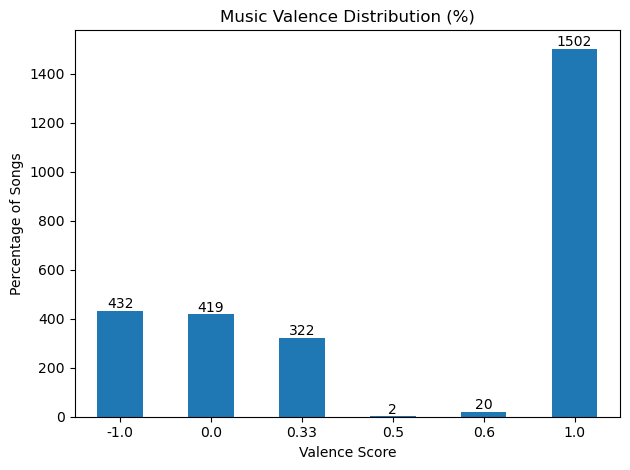

In [374]:
valence_pct = music["valence"].round(2).value_counts(normalize=True).sort_index()

(valence_pct * 100).plot(kind="bar")

valence_counts = music["valence"].round(2).value_counts().sort_index()

ax = valence_counts.plot(kind="bar")

plt.title("Distribution of Music Valence")
plt.xlabel("Valence Score")
plt.ylabel("Number of Songs")

# add count labels
for i, v in enumerate(valence_counts):
    ax.text(i, v + 10, str(v), ha='center')


plt.title("Music Valence Distribution (%)")
plt.xlabel("Valence Score")
plt.ylabel("Percentage of Songs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

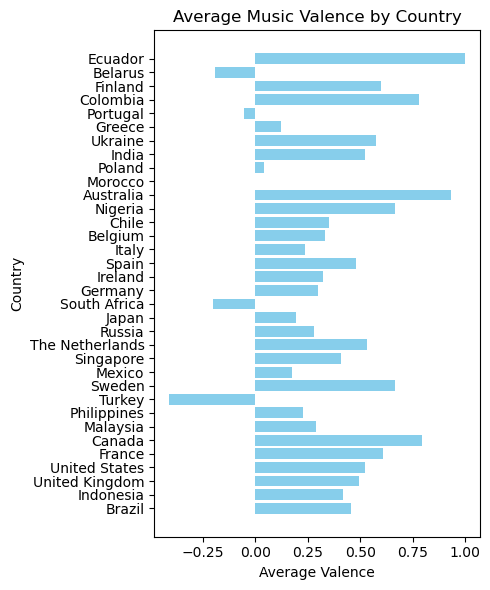

In [375]:
country_stats = (
    music.groupby("country-id")["valence"]
    .agg(["mean", "count"])
    .reset_index()
)
#Filtered out contries with less than 5 songs to ensure more reliable average valence scores.
country_stats = country_stats[country_stats["count"] >= 5]

country_mapping = pd.read_csv('raw_data/country_mapping.csv')
country_stats = pd.merge(country_stats, country_mapping, on='country-id', how='inner')
 
plt.figure(figsize=(5,6))
plt.barh(country_stats['country'], country_stats['mean'], color='skyblue')

plt.xlabel("Average Valence")
plt.ylabel("Country")
plt.title("Average Music Valence by Country")

plt.tight_layout()
plt.show()


### Calculating Composite Mental Health Score with PCA

Since we converted the mental health survey responses to numerical value, we can then use PCA below to convert these 12 factors into a composite score. Here, a higher `composite_mh_score` represents poorer mental health for an individual.

In [376]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

survey_features = ['family_history', 'treatment', 'Growing_Stress', 'Changes_Habits', 
    'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 
    'Work_Interest', 'Social_Weakness', 'mental_health_interview', 
    'care_options', 'Days_Indoors']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(mh[survey_features])

pca = PCA(n_components=1)

mh['composite_mh_score'] = pca.fit_transform(scaled_data)

In [377]:
mh.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Month,Season,composite_mh_score
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.5,8,Summer,0.274544
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,0.0,8,Summer,0.947969
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0,8,Summer,2.009174
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.5,1.0,8,Summer,1.732625
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,1,1.0,0.0,1.0,1,0,0.0,1.0,0.0,1.0,8,Summer,2.009174


#### Plots for Mental Health

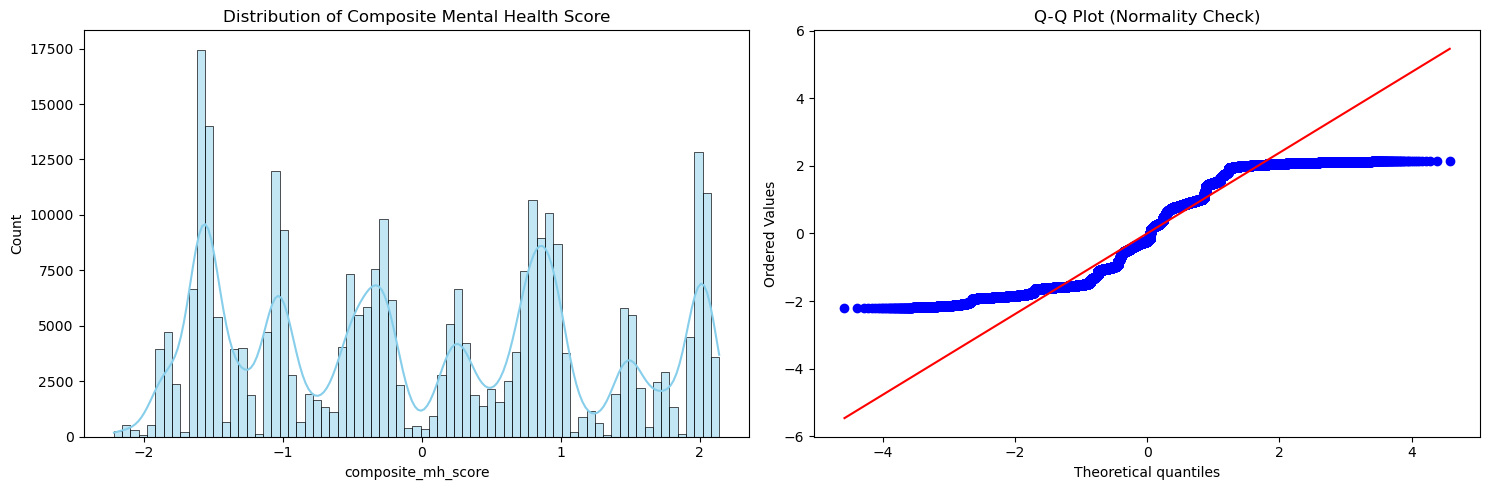

In [378]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(mh['composite_mh_score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Composite Mental Health Score')

# Q-Q Plot
stats.probplot(mh['composite_mh_score'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
plt.tight_layout()
plt.show()

/var/folders/3j/drj0214n2bqdbrn4vd1d19_m0000gn/T/ipykernel_35274/1746070125.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=season_order, patch_artist=True,


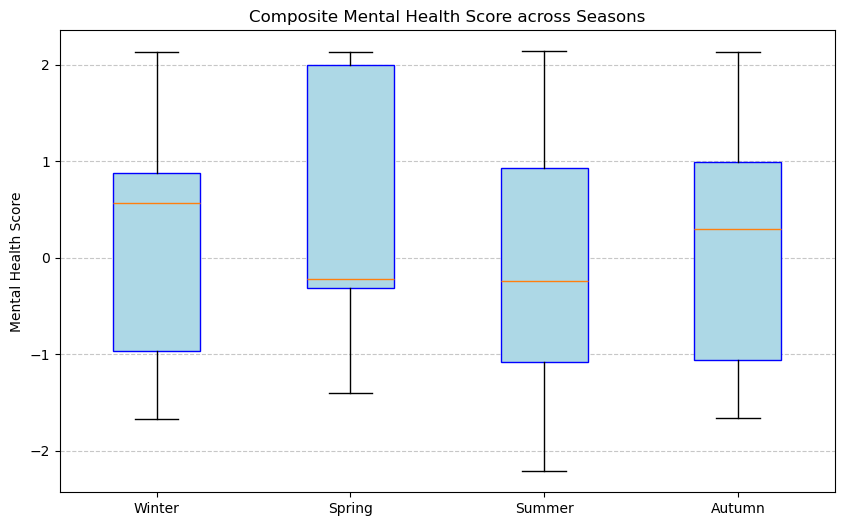

In [379]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
data_to_plot = [mh[mh['Season'] == s]['composite_mh_score'] for s in season_order]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=season_order, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', color='blue'))

plt.title('Composite Mental Health Score across Seasons')
plt.ylabel('Mental Health Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## KS-test

Below we will use a two-sample K-S test to check whether the distribution of mental health reports across months matches the distribution of listening habits across months. 

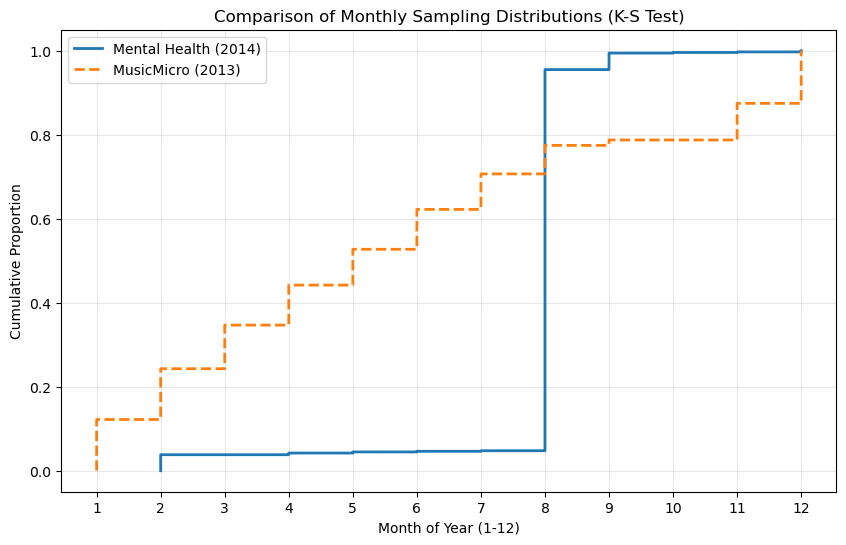

Our p-value is: 0.0


In [380]:
mh_months = mh['Timestamp'].dt.month
music_months = music['month']

ks_stat, p_val = ks_2samp(mh_months, music_months)

def get_ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y

x_mh, y_mh = get_ecdf(mh_months)
x_music, y_music = get_ecdf(music_months)

plt.figure(figsize=(10, 6))
plt.step(x_mh, y_mh, label='Mental Health (2014)', where='post', linewidth=2)
plt.step(x_music, y_music, label='MusicMicro (2013)', where='post', linestyle='--', linewidth=2)

plt.title('Comparison of Monthly Sampling Distributions (K-S Test)')
plt.xlabel('Month of Year (1-12)')
plt.ylabel('Cumulative Proportion')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Our p-value is: {p_val}")

As you can see above, our p-value is 0 and there appears to be a large spike in entries in the 8th month, August. As you can see below, there is a class imbalance in the mental health dataset where a vast majority of entries come from August.

In [381]:
mh.value_counts('Month')

Month
8     265316
9      11486
2      11140
4       1170
12       824
5        780
6        434
10       434
7        390
11       390
Name: count, dtype: int64

To try and fix this class imbalance, we will attempt to uniformly randomly downsample our data so that there are more equal amounts across months. This will ensure that each month carries roughly similar weight in the ECDF.

/var/folders/3j/drj0214n2bqdbrn4vd1d19_m0000gn/T/ipykernel_35274/2002254948.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mh_balanced = mh.groupby('month').apply(


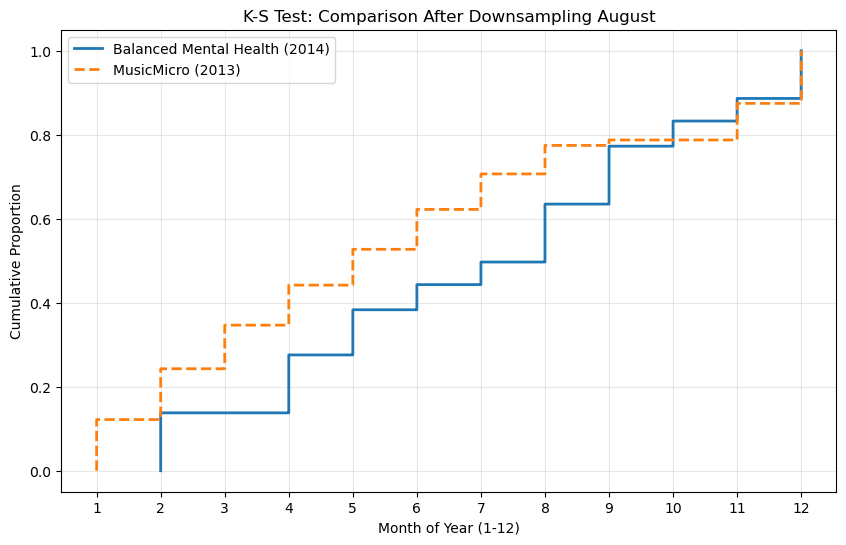

Our new p-value: 3.267024646590727e-76


In [382]:
mh['month'] = mh['Timestamp'].dt.month

target_n = 1000 
mh_balanced = mh.groupby('month').apply(
    lambda x: x.sample(n=min(len(x), target_n), random_state=42)
).reset_index(drop=True)

ks_stat, p_val = ks_2samp(mh_balanced['month'], music['month'])

def get_ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y

x_mh, y_mh = get_ecdf(mh_balanced['month'])
x_music, y_music = get_ecdf(music['month'])

plt.figure(figsize=(10, 6))
plt.step(x_mh, y_mh, label='Balanced Mental Health (2014)', where='post', linewidth=2)
plt.step(x_music, y_music, label='MusicMicro (2013)', where='post', linestyle='--', linewidth=2)

plt.title('K-S Test: Comparison After Downsampling August')
plt.xlabel('Month of Year (1-12)')
plt.ylabel('Cumulative Proportion')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Our new p-value: {p_val}")

Despite out efforts, our p-value is still incredibly small, meaning we REJECT the null hypothesis that these two datasets come from the same distribution. If we altered the dataset any more we would run the risk of manipulating the data too much to fit what we're looking for. 

## Chi-squared test

In [383]:
# mental data shape and samp
print(mh.shape)
mh.head()

(292364, 21)


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,...,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Month,Season,composite_mh_score,month
0,2014-08-27 11:29:31,Female,United States,Corporate,Unknown,0,1,1,1.0,0.0,...,1,0,0.0,1.0,0.0,0.5,8,Summer,0.274544,8
1,2014-08-27 11:31:50,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,...,1,0,0.0,1.0,0.0,0.0,8,Summer,0.947969,8
2,2014-08-27 11:32:39,Female,United States,Corporate,Unknown,1,1,1,1.0,0.0,...,1,0,0.0,1.0,0.0,1.0,8,Summer,2.009174,8
3,2014-08-27 11:37:59,Female,United States,Corporate,No,1,1,1,1.0,0.0,...,1,0,0.0,1.0,0.5,1.0,8,Summer,1.732625,8
4,2014-08-27 11:43:36,Female,United States,Corporate,No,1,1,1,1.0,0.0,...,1,0,0.0,1.0,0.0,1.0,8,Summer,2.009174,8


In [384]:
# filter mental data to year (2014 ONLY) and country

clean_mental = pd.DataFrame()

clean_mental['Year'] = mh.Timestamp.apply(lambda x: x.year)
clean_mental['Country'] = mh.Country

clean_mental.query('Year == 2014', inplace=True)

In [385]:
# clean and filter music data for year and country
clean_music = pd.DataFrame()

clean_music['Year'] = (2013 * np.ones(music.shape[0])).astype(int)
clean_music['Country'] = (
    music['country'] # grab country column
    .replace('The Netherlands', 'Netherlands') # match country titles to those in mental set
)

clean_music.head()

,Year,Country
0,2013,Brazil
1,2013,Brazil
2,2013,Brazil
3,2013,United States
4,2013,Netherlands


In [386]:
# merge clean_music and clean_mental
clean_full = pd.concat([clean_mental, clean_music], axis=0)

clean_full.head()

,Year,Country
0,2014,United States
1,2014,United States
2,2014,United States
3,2014,United States
4,2014,United States


In [387]:
# create crosstab table

O_table = pd.crosstab(clean_full['Year'], clean_full['Country'])
n_i = O_table.sum(axis=1)

p_table = O_table.div(n_i, axis=0)
p_table

Country,Argentina,Armenia,Australia,Barbados,Belarus,Belgium,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,...,Thailand,Togo,Turkey,Ukraine,United Arab Emirates,United Kingdom,United States,Venezuela,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
2013,0.001112,0.000371,0.002225,0.000371,0.002595,0.001854,0.000371,0.000000,0.000371,0.199852,...,0.000742,0.000371,0.035224,0.004079,0.000742,0.185391,0.198369,0.000742,0.000371,0.000371
2014,0.000000,0.000000,0.018920,0.000000,0.000000,0.002972,0.000000,0.001407,0.000000,0.007033,...,0.001407,0.000000,0.000000,0.000000,0.000000,0.173817,0.596401,0.000000,0.000000,0.000000


In [388]:
N = O_table.values.sum()

p_table.loc['total'] = O_table.sum(axis=0) / N

p_table

Country,Argentina,Armenia,Australia,Barbados,Belarus,Belgium,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,...,Thailand,Togo,Turkey,Ukraine,United Arab Emirates,United Kingdom,United States,Venezuela,Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
2013,0.001112,0.000371,0.002225,0.000371,0.002595,0.001854,0.000371,0.000000,0.000371,0.199852,...,0.000742,0.000371,0.035224,0.004079,0.000742,0.185391,0.198369,0.000742,0.000371,0.000371
2014,0.000000,0.000000,0.018920,0.000000,0.000000,0.002972,0.000000,0.001407,0.000000,0.007033,...,0.001407,0.000000,0.000000,0.000000,0.000000,0.173817,0.596401,0.000000,0.000000,0.000000
total,0.000011,0.000004,0.018759,0.000004,0.000025,0.002961,0.000004,0.001393,0.000004,0.008890,...,0.001400,0.000004,0.000339,0.000039,0.000007,0.173929,0.592567,0.000007,0.000004,0.000004


Would use a hypothesis test for homogeneity. \

$H_0:$ There is no difference in the distribution of countries between 2013 and 2014. \
$H_1:$ There is a difference in the distribution of countries between 2013 and 2014.

In [389]:
p_ij, p_j = p_table.iloc[0:2], p_table.iloc[2]
T = (((p_ij - p_j)**2 / p_j).sum(axis=1) * n_i).sum()

T

np.float64(73203.52434736515)

In [390]:
r, k = O_table.shape
df = (r-1) * (k-1)

pvalue = 1 - stats.chi2.cdf(T, df)
pvalue

np.float64(0.0)

In [391]:
alpha = 0.05
pvalue < alpha

np.True_

There is sufficient evidence against the null hypothesis, so we reject thenull in favor of the alternative. That is thereis sufficient evidence to conclude that there is a difference in distribution of countries between 2013 and 2014.

In [392]:
mh['year'] = pd.to_datetime(mh['Timestamp']).dt.year
mh = mh[mh['year'] == 2014]

## Q-Q Plot

Before our ACF and F-test, we need to test for normality for both the composite mental health score and music valence by plotting the quantiles of both against the normal distribution.

In [393]:
model = smf.ols("composite_mh_score ~ C(Season)", data=mh).fit()

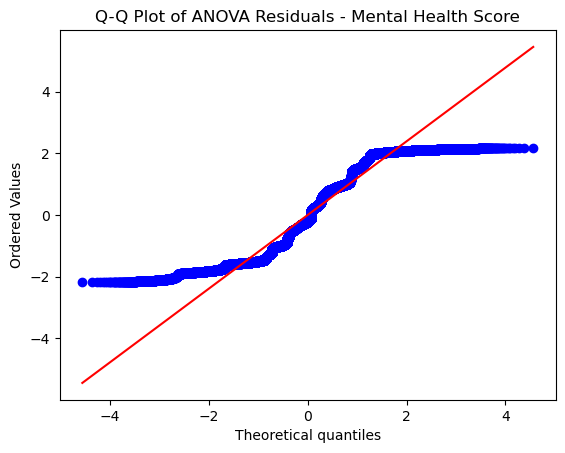

In [394]:
residuals = model.resid
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals - Mental Health Score")
plt.show()

The S-curve deviation in the Q-Q plot, confirmed by the histogram of residuals, reveals that the composite mental health score follows a discrete rather than continuous distribution. This pattern likely arises from underlying survey items being Likert-scale or binary responses, which then makes the composite score inherit this discreteness in PCA.

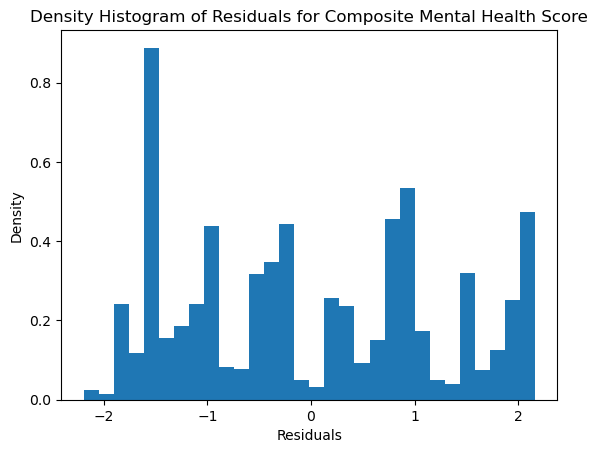

In [395]:
plt.hist(residuals, bins=30, density=True)
plt.title("Density Histogram of Residuals for Composite Mental Health Score")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

In [396]:
model_valence = smf.ols("valence ~ C(season)", data=music).fit()
residuals_valence = model_valence.resid

Text(0.5, 1.0, 'Q-Q Plot of ANOVA Residuals - Music Valence')

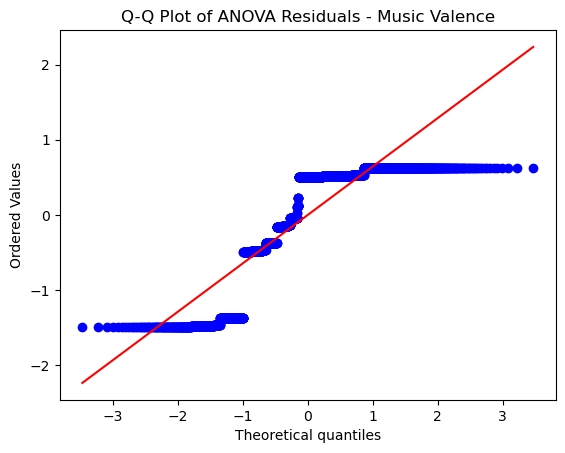

In [397]:
stats.probplot(residuals_valence, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals - Music Valence")

The step-like pattern with hard compression at ±1 reflects near-discrete clustering (tracks rated 0 or 1). This near-discrete clustering reinforces our use for Q-Q plots over the K-S test, which would have hidden the discrete structure (showing only a general deviation from the smooth normal CDF).

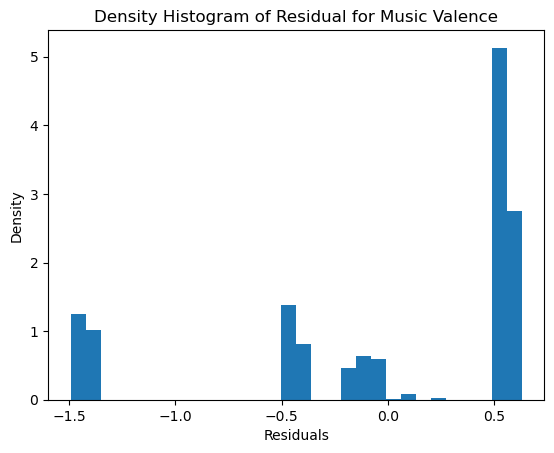

In [398]:
plt.hist(residuals_valence, bins=30, density=True)
plt.title("Density Histogram of Residual for Music Valence")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

The clustering distribution suggests that we may have to deviate from our originally pitched F-test, which requires normality. We would either have to add noise to our data to make the music valence more normal, or swtich to a different test that does not require normality like the Kruskal-Wallis test.

In [399]:
mh_monthly = mh.groupby(['Season']).composite_mh_score.mean().reset_index()
music_monthly = music.groupby(['season']).valence.mean().reset_index()

## ACF Test

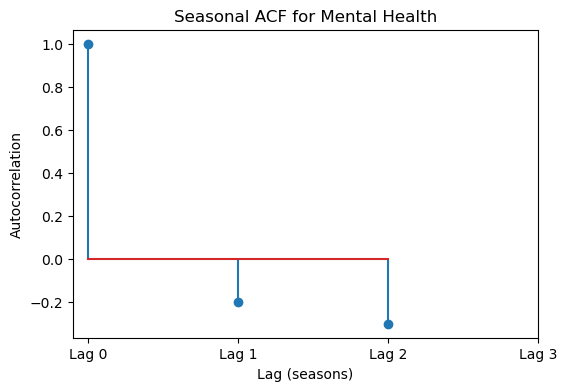

In [400]:
mh_acf = acf(mh_monthly['composite_mh_score'].values, nlags=3)

plt.figure(figsize=(6,4))
plt.stem(range(len(mh_acf)), mh_acf)
plt.xlabel('Lag (seasons)')
plt.ylabel('Autocorrelation')
plt.title('Seasonal ACF for Mental Health')
plt.xticks(range(4), ['Lag 0','Lag 1','Lag 2','Lag 3'])
plt.show()


- The lag-1 value of -0.75 is a strong negative autocorrelation. This means if mental health scores are high one month, they tend to be low the next month, and vice versa. For example, if mental health is low in Winter, it’s likely higher in Spring. 
- The lag-2 value of +0.3 partially recovers (high → low → moderate), meaning mental health has a moderate tendency to return toward the original value.
- The lag-3 value of -0.05 is near zero, meaning that there is little correlation between a season and the season three steps ahead.

Mental health shows clear seasonality: opposite in adjacent seasons and partially recovers two seasons later. This fits the expected seasonal pattern for SAD: winter lows, summer highs.

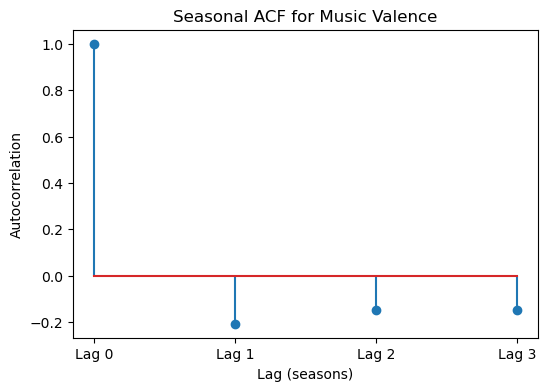

In [401]:
valence_acf = acf(music_monthly['valence'].values, nlags=3)

plt.figure(figsize=(6,4))
plt.stem(range(len(valence_acf)), valence_acf)
plt.xlabel('Lag (seasons)')
plt.ylabel('Autocorrelation')
plt.title('Seasonal ACF for Music Valence')
plt.xticks(range(4), ['Lag 0','Lag 1','Lag 2','Lag 3'])
plt.show()

All three lags are small negative values hovering around -0.15 to -0.21. This means music valence doesn't particularly show a meaningful autocorrelation. Knowing last season's average valence doesn't tell much about this month's. This suggests that people’s music listening habits don't reflect seasonal changes as strongly as mental health does.

## F-test

In [402]:
# Group data by season
mh_groups = [group['composite_mh_score'].values for name, group in mh.groupby('Season')]
valence_groups = [group['valence'].values for name, group in music.groupby('season')]

# Perform F-test
f_mh, p_mh = f_oneway(*mh_groups)
f_val, p_val = f_oneway(*valence_groups)

print("F-test for seasonal differences (Mental Health): F =", f_mh, "p =", p_mh)
print("F-test for seasonal differences (Music Valence): F =", f_val, "p =", p_val)

F-test for seasonal differences (Mental Health): F = 53.92064979295109 p = 3.864666517519781e-24
F-test for seasonal differences (Music Valence): F = 4.748093024504279 p = 0.0026335753939971613


The F-test on the mental health dataset produced **F = 259**. This is very high, showing that the differences between seasons are much larger than the variability within each season. With a p-value of virutally 0, we can say that season is a powerful predictor of mental health score.

The F-test on music valence produced **F = 4.75**. While this is not as high as the mental health scores, we obtain a p-value of **0.0026**, which is still evidence to suggest that music valence differs between seasons.

From the F-test, we can conclude that the type of music people listen to does vary slightly across seasons, but the effect is much smaller than the variation in mental health.

## Kruskal-Wallis Test

In [403]:
mh_groups = [group['composite_mh_score'].values 
             for name, group in mh.groupby('Season')]

stat_mh, p_mh = kruskal(*mh_groups)

print("Kruskal-Wallis (Mental Health):")
print("H-statistic:", stat_mh)
print("p-value:", p_mh)

Kruskal-Wallis (Mental Health):
H-statistic: 111.3712407002227
p-value: 6.547000296453663e-25


In [404]:
valence_groups = [group['valence'].values 
                  for name, group in music.groupby('season')]

stat_val, p_val = kruskal(*valence_groups)

print("Kruskal-Wallis (Music Valence):")
print("H-statistic:", stat_val)
print("p-value:", p_val)

Kruskal-Wallis (Music Valence):
H-statistic: 8.65027800121472
p-value: 0.03432079293583533


Because Q-Q plots indicated that the distributions deviate from normality, a Kruskal–Wallis test was performed in addition to the ANOVA F-test. The results were consistent across both tests, confirming that seasonal differences in mental health and music valence are statistically significant.

Our results suggest:

- Mental health clearly changes across seasons globally.
- Music mood (valence) also changes slightly across seasons.
- The seasonal effect is much stronger in mental health than in music listening behavior.

Music might partially reflect seasonal mood shifts, but it might not be a perfect proxy for population mental health.